# Test Classificatori e Valutazione della Sostenibilità
## Real+Augmented vs Real+Synth

Confronto delle prestazioni sul test set composto da 438 immagini reali (365 sani / 73 malati) tra due strategie di addestramento:

| Configurazione | Dati di Training | Riferimento |
|---|---|---|
| **Real+Augmented** | Immagini reali + augmentation tradizionale (geometrica) | Notebook 10 |
| **Real+Synth** | Immagini reali + immagini sintetiche (modelli di diffusione) | Notebook 06 |

- Lo scopo della valutazione è determinare se l'introduzione di dati sintetici migliori le prestazioni del classificatore in maniera tale da giustificarne il costo computazionale ed i relativi consumi energetici.
- Per un confronto equo ed evitare data leakage viene applicato lo stesso preprocessing del training.
- La soglia di Youden viene ricalcolata per entrambi i modelli sul validation set.
- La soglia ottimale viene congelata e applicata alle probabilità del test set.

#### Setup percorsi

In [1]:
import os, sys
from pathlib import Path

#esecuzione su colab (con drive) oppure in locale/WSL
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')                              #monta drive (utile per Colab/prof)
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    #individua la root MammoDiffusion risalendo le cartelle
    cands = [Path.cwd(), *Path.cwd().parents]
    root = next((p for p in cands if (p / 'data' / 'processed').is_dir()), Path.cwd())
    BASE_PATH = f"{root}/"
print("percorso:", BASE_PATH)


percorso: /mnt/c/Users/samto/Desktop/MammoDiffusion/


#### Import e Configurazione GPU

In [2]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   #silenzia i log di TensorFlow 

import zipfile, gdown, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, precision_score, recall_score,
    f1_score, accuracy_score, precision_recall_curve, average_precision_score
)

tf.get_logger().setLevel('ERROR')          #silenzia warning di python

#allocazione dinamica memoria GPU per evitare OOM
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("set_memory_growth:", e)

#### Configurazione
- Definizione dei percorsi per i modelli da valutare `Real+Augmented` e `Real+Synth`, costanti per il preprocessing delle immagini e directory di output.

In [3]:
#percorsi e id drive (fallback) per modello Real+Augmented
TRAD_AUG_EXP_DIR        = os.path.join(BASE_PATH, 'experiments', 'exp_trad_aug_resnet50')
TRAD_AUG_MODEL_DRIVE_ID = ''      #id drive del .keras (vuoto in locale; riempire per Colab/prof)

#percorsi, id drive (fallback) e soglia per modello Real+Synth
REAL_SYNTH_EXP_DIR              = os.path.join(BASE_PATH, 'experiments', 'exp20260617_real_synth_resnet50_fine_tuned_batch_size_16')
REAL_SYNTH_MODEL_DRIVE_ID       = '11f9pcL8kbLz7hi6i3lqDuferljdRl2uV'
REAL_SYNTH_REF_THRESHOLD_YOUDEN = 0.269

MODELLI_ATTIVI = ['Real+Augmented', 'Real+Synth']     #modelli da valutare

#path e id drive (fallback) per dataset preprocessato
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
TEST_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'test.csv')
VAL_CSV_PATH  = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'val.csv')

#parametri preprocessing
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])
AUTOTUNE = tf.data.AUTOTUNE

#cartelle di output dedicate per evitare conflitti
OUTPUT_DIR      = os.path.join(BASE_PATH, 'results', 'test_trad_aug_vs_real_synth')
FIGURES_DIR     = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR      = os.path.join(OUTPUT_DIR, 'tables')
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, 'predictions')
MODELS_DIR      = os.path.join(OUTPUT_DIR, 'models')

for d in (OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, PREDICTIONS_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)

#valida lista modelli attivi
_VALIDI = {'Real+Augmented', 'Real+Synth'}
assert 1 <= len(MODELLI_ATTIVI) and set(MODELLI_ATTIVI) <= _VALIDI, "MODELLI_ATTIVI deve essere sottoinsieme di %s" % _VALIDI

print("output in:", OUTPUT_DIR)
print("modelli:", MODELLI_ATTIVI)

output in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth
modelli: ['Real+Augmented', 'Real+Synth']


I0000 00:00:1781891317.325686   42421 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


#### Verifica presenza dataset preprocessato

In [4]:
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')   #percorso archivio zip

#verifica presenza dei file csv e della prima immagine
def verifica_processed_data():
    if not (os.path.isfile(TEST_CSV_PATH) and os.path.isfile(VAL_CSV_PATH)):
        return False
    try:
        first_path = pd.read_csv(TEST_CSV_PATH)['processed_path'].iloc[0]       #legge percorso prima immagine
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

#se dataset mancante esegue download
if not verifica_processed_data():
    print("dataset non trovato - download da drive")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)    #scarica archivio
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))              #estrae contenuto
    os.remove(PROCESSED_ZIP)       
    print("dataset estratto")
else:
    print("dataset gia presente")

dataset gia presente


#### Creazione Validation e Test dataset
- Si utilizzano solo immagini reali con preprocessing identico al training.
- La soglia di Youden viene calcolata sul validation set e la valutazione viene svolta sul test set.

In [5]:
#carica e preprocessa singola immagine
def caricamento_preprocessing(percorso, etichetta):
    raw = tf.io.read_file(percorso)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)   #decodifica in grayscale
    img = tf.image.resize(img, IMG_SIZE)                                    #ridimensiona
    img = tf.cast(img, tf.float32) / 255.0                                  #normalizza in range [0,1]
    img = tf.repeat(img, repeats=3, axis=-1)                                #duplica su 3 canali RGB
    img = (img - IMAGENET_MEAN) / IMAGENET_STD                              #normalizza con statistiche ImageNet
    return img, tf.cast(etichetta, tf.float32)

#crea pipeline dati da dataframe
def crea_dataset(df):
    percorsi  = [os.path.join(BASE_PATH, p) for p in df['processed_path'].values] #percorsi delle immagini
    etichette = df['cancer'].values                                         
    ds = tf.data.Dataset.from_tensor_slices((percorsi, etichette))          #crea dataset
    ds = ds.map(lambda p, l: caricamento_preprocessing(p, l), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)                          #raggruppa in batch e precarica

#carica dataframe validation e test
df_val  = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)
df_test = pd.read_csv(TEST_CSV_PATH).reset_index(drop=True)

#stampa statistiche classi
print("VAL :", len(df_val),  "img  (malato=%d, sano=%d)" % ((df_val['cancer']==1).sum(),  (df_val['cancer']==0).sum()))
print("TEST:", len(df_test), "img  (malato=%d, sano=%d)" % ((df_test['cancer']==1).sum(), (df_test['cancer']==0).sum()))

#istanzia pipeline dati
val_ds  = crea_dataset(df_val)
test_ds = crea_dataset(df_test)
print("dataset val/test pronti")

VAL : 437 img  (malato=73, sano=364)
TEST: 438 img  (malato=73, sano=365)
dataset val/test pronti


#### Caricamento modelli
- Caricamento da /experiments, cache o Drive.
- I modelli vengono caricati con `compile=False` poiché verrà eseguita la sola inferenza.

In [6]:
#percorsi e id drive (fallback) dei modelli da valutare
MODELS_CONFIG = {
    'Real+Augmented': {
        'percorso_exp':     os.path.join(TRAD_AUG_EXP_DIR, 'trad_aug_resnet50_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,       'trad_aug_resnet50_final_best.keras'),
        'drive_id':         TRAD_AUG_MODEL_DRIVE_ID,
    },
    'Real+Synth': {
        'percorso_exp':     os.path.join(REAL_SYNTH_EXP_DIR, 'real_synth_resnet50_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,         'real_synth_resnet50_final_best.keras'),
        'drive_id':         REAL_SYNTH_MODEL_DRIVE_ID,
    },
}

#carica modello da /experiments, cache locale o download da drive (fallback)
def carica_modello(nome, config):
    if os.path.isfile(config['percorso_exp']):
        print("[%s] caricamento da /experiments" % nome)
        return keras.models.load_model(config['percorso_exp'], compile=False)
    if os.path.isfile(config['percorso_modello']):
        print("[%s] caricamento da cache" % nome)
        return keras.models.load_model(config['percorso_modello'], compile=False)
    if not config['drive_id']:
        raise FileNotFoundError("[%s] modello e id drive mancanti" % nome)
    print("[%s] download da drive" % nome)
    gdown.download(id=config['drive_id'], output=config['percorso_modello'], quiet=False)
    return keras.models.load_model(config['percorso_modello'], compile=False)

modelli = {nome: carica_modello(nome, MODELS_CONFIG[nome]) for nome in MODELLI_ATTIVI}
print("modelli caricati:", list(modelli))


[Real+Augmented] caricamento da /experiments
[Real+Synth] caricamento da /experiments
modelli caricati: ['Real+Augmented', 'Real+Synth']


#### Soglia di Youden
- Per entrambi i modelli la soglia ottimale (punto di Youden) viene calcolata sul validation set.
- La soglia viene congelata e applicata al test set per evitare data leakage.

In [7]:
#estrae probabilità ed etichette da dataset
def predici(modello, dataset):
    y_true, y_prob = [], []
    for imgs, labels in dataset:
        y_prob.extend(modello.predict(imgs, verbose=0).flatten())
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_prob)

#calcola soglia di Youden
def soglia_youden(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    return float(thr[np.argmax(tpr - fpr)])

#esegue predizioni su validation set per ricavare soglie
val_true = None
val_probs, soglie = {}, {}
for nome in MODELLI_ATTIVI:
    yt, yp = predici(modelli[nome], val_ds)
    if val_true is None:
        val_true = yt
    else:
        assert np.array_equal(val_true, yt), "ordine y_true incoerente"     #verifica coerenza ordine tra modelli
    val_probs[nome], soglie[nome] = yp, soglia_youden(yt, yp)

print("soglie di Youden (VAL):")
for nome in MODELLI_ATTIVI:
    print("  %-12s %.4f" % (nome, soglie[nome]))

#verifica scostamento soglia real_synth da valore atteso
if 'Real+Synth' in MODELLI_ATTIVI:
    delta_thr = abs(soglie['Real+Synth'] - REAL_SYNTH_REF_THRESHOLD_YOUDEN)
    esito = "ok" if delta_thr <= 0.02 else "scostamento > 0.02"
    print("\ncross-check soglia real_synth: %.4f vs riferimento %.4f (delta %.4f) -> %s" % (
        soglie['Real+Synth'], REAL_SYNTH_REF_THRESHOLD_YOUDEN, delta_thr, esito))

I0000 00:00:1781891345.648282   42613 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


soglie di Youden (VAL):
  Real+Augmented 0.4278
  Real+Synth   0.2854

cross-check soglia real_synth: 0.2854 vs riferimento 0.2690 (delta 0.0164) -> ok


#### Predizioni sul Test Set
- Predizioni sul test set per i modelli.
- Si convertono le probabilità in etichette binarie utilizzando le soglie calcolate sul validation set.
- Risultati salvati su CSV.

In [8]:
#esegue predizioni su test set per ogni modello
test_true = None
test_probs = {}
for nome in MODELLI_ATTIVI:
    yt, yp = predici(modelli[nome], test_ds)
    if test_true is None:
        test_true = yt
    else:
        assert np.array_equal(test_true, yt), "ordine y_true incoerente"    #verifica coerenza ordine etichette
    test_probs[nome] = yp
print("predizioni test completate per:", list(test_probs))

#formatta nomi stringhe per intestazioni colonne
def _key(nome):
    return nome.lower().replace('+', '_')

#costruisce dataframe con probabilità e predizioni binarie
df_pred = df_test[['processed_path', 'cancer']].copy().rename(columns={'cancer': 'label_true'})
for nome in MODELLI_ATTIVI:
    k = _key(nome)
    df_pred['prob_' + k] = test_probs[nome]
    df_pred['pred_' + k] = (test_probs[nome] >= soglie[nome]).astype(int)

#salva risultati in formato csv
preds_path = os.path.join(PREDICTIONS_DIR, 'test_predictions.csv')
df_pred.to_csv(preds_path, index=False)
print("predizioni salvate in:", preds_path)

predizioni test completate per: ['Real+Augmented', 'Real+Synth']
predizioni salvate in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/predictions/test_predictions.csv


#### Valutazione - Metriche per Configurazione
- Vengono calcolate le metriche principali (AUC, F1, Recall, Accuracy, Precision) per i modelli.
- Viene calcolata la differenza di prestazioni tra i modelli per valutare l'impatto della generazione sintetica.
- Le metriche vengono salvate su file JSON.

In [9]:
#inizializza dati per calcolo metriche
CLASSIFICATORI = {nome: (test_probs[nome], soglie[nome]) for nome in MODELLI_ATTIVI}

#calcola e stampa metriche per ogni modello
all_metrics = {}
for nome, (probs, thr) in CLASSIFICATORI.items():
    fpr, tpr, _ = roc_curve(test_true, probs)
    y_pred = (probs >= thr).astype(int)
    all_metrics[nome] = {
        'auc':       round(float(roc_auc_score(test_true, probs)), 4),
        'threshold': round(float(thr), 4),
        'accuracy':  round(float(accuracy_score(test_true, y_pred)), 4),
        'precision': round(float(precision_score(test_true, y_pred, pos_label=1, zero_division=0)), 4),
        'recall':    round(float(recall_score(test_true, y_pred, pos_label=1, zero_division=0)), 4),
        'f1':        round(float(f1_score(test_true, y_pred, pos_label=1, zero_division=0)), 4),
        'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred,
    }
    print("\n[%s]" % nome)
    print("  AUC: %.4f | F1: %.4f | recall: %.4f | acc: %.4f | soglia: %.3f" % (
        all_metrics[nome]['auc'], all_metrics[nome]['f1'], all_metrics[nome]['recall'],
        all_metrics[nome]['accuracy'], all_metrics[nome]['threshold']))
    print(classification_report(test_true, y_pred, target_names=['Sano', 'Malato']))

#calcola differenza di prestazioni se entrambi i modelli sono attivi
if 'Real+Augmented' in all_metrics and 'Real+Synth' in all_metrics:
    delta = {k: round(all_metrics['Real+Synth'][k] - all_metrics['Real+Augmented'][k], 4)
             for k in ('auc', 'f1', 'recall', 'accuracy')}
    print("\ndelta (Real+Synth - Real+Augmented):", delta)
else:
    delta = {}

#salva risultati in json filtrando array non serializzabili
metrics_to_save = {
    'modelli_attivi': MODELLI_ATTIVI,
    'configs': {k: {m: v for m, v in vals.items() if m not in ('fpr', 'tpr', 'y_pred')}
                for k, vals in all_metrics.items()},
    'delta_real_synth_minus_real_augmented': delta,
}
out_json = os.path.join(TABLES_DIR, 'test_metrics_trad_aug_vs_real_synth.json')
with open(out_json, 'w') as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)
print("\nmetriche salvate in:", out_json)


[Real+Augmented]
  AUC: 0.5541 | F1: 0.2721 | recall: 0.5068 | acc: 0.5479 | soglia: 0.428
              precision    recall  f1-score   support

        Sano       0.85      0.56      0.67       365
      Malato       0.19      0.51      0.27        73

    accuracy                           0.55       438
   macro avg       0.52      0.53      0.47       438
weighted avg       0.74      0.55      0.61       438


[Real+Synth]
  AUC: 0.6122 | F1: 0.3203 | recall: 0.6164 | acc: 0.5639 | soglia: 0.285
              precision    recall  f1-score   support

        Sano       0.88      0.55      0.68       365
      Malato       0.22      0.62      0.32        73

    accuracy                           0.56       438
   macro avg       0.55      0.58      0.50       438
weighted avg       0.77      0.56      0.62       438


delta (Real+Synth - Real+Augmented): {'auc': 0.0581, 'f1': 0.0482, 'recall': 0.1096, 'accuracy': 0.016}

metriche salvate in: /mnt/c/Users/samto/Desktop/MammoDiffusi

#### Visualizzazione Curve ROC

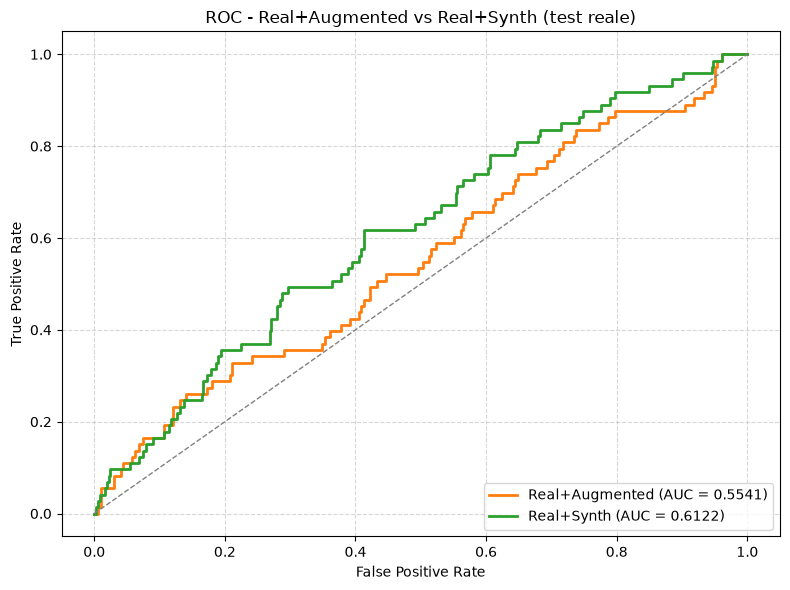

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/roc_trad_aug_vs_real_synth.png


In [10]:
COLORS = {'Real+Augmented': 'tab:orange', 'Real+Synth': 'tab:green'}
fig, ax = plt.subplots(figsize=(8, 6))

#ROC per ogni modello
for nome, m in all_metrics.items():
    ax.plot(m['fpr'], m['tpr'], color=COLORS[nome], lw=2, label="%s (AUC = %.4f)" % (nome, m['auc']))

ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)                           #random guess
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')  
ax.set_title('ROC - Real+Augmented vs Real+Synth (test reale)')
ax.legend(loc='lower right'); ax.grid(True, linestyle='--', alpha=0.5)  

plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'roc_trad_aug_vs_real_synth.png')
fig.savefig(roc_path, dpi=150, bbox_inches='tight')                        
plt.show()
print("salvato in:", roc_path)

#### Visualizzazione Precision-Recall
- Su classi sbilanciate la PR curve è più informativa della ROC poichè non viene falsata dalla numerosità dei negativi.
- La linea grigia indica il classificatore casuale con la proporzione di positivi del test set.

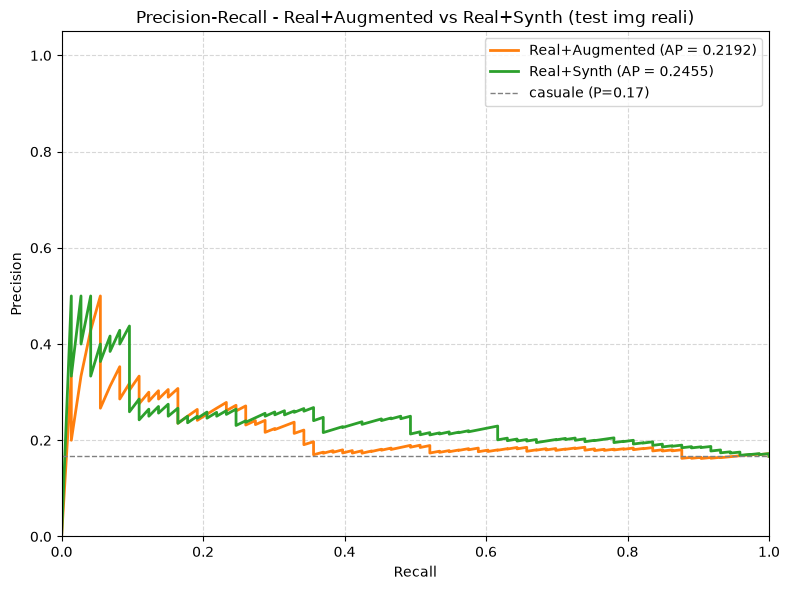

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/pr_trad_aug_vs_real_synth.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

#PR per ogni modello
for nome, (probs, _) in CLASSIFICATORI.items():
    prec, rec, _ = precision_recall_curve(test_true, probs)
    ap = average_precision_score(test_true, probs)
    ax.plot(rec, prec, color=COLORS[nome], lw=2, label="%s (AP = %.4f)" % (nome, ap))

baseline_pr = test_true.mean()      #proporzione di positivi nel test set          
                                   
ax.axhline(y=baseline_pr, color='gray', linestyle='--', lw=1, label="casuale (P=%.2f)" % baseline_pr)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_title('Precision-Recall - Real+Augmented vs Real+Synth (test img reali)')
ax.legend(loc='upper right'); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
pr_path = os.path.join(FIGURES_DIR, 'pr_trad_aug_vs_real_synth.png')
fig.savefig(pr_path, dpi=150, bbox_inches='tight')
plt.show()
print("salvato in:", pr_path)

#### Visualizzazione Matrici di Confusione

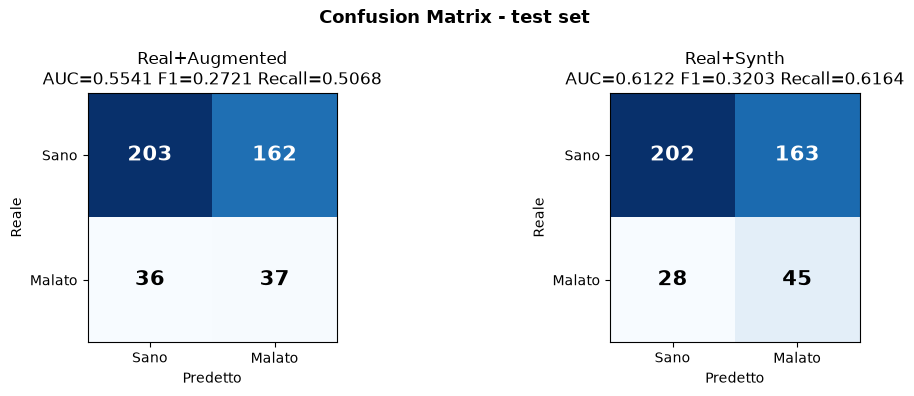

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/cm_trad_aug_vs_real_synth.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (nome, m) in zip(axes, all_metrics.items()):
    cm = confusion_matrix(test_true, m['y_pred'])
    ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])                                    #tick
    ax.set_xticklabels(['Sano', 'Malato']); ax.set_yticklabels(['Sano', 'Malato'])  
    ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
    ax.set_title("%s\nAUC=%.4f F1=%.4f Recall=%.4f" % (nome, m['auc'], m['f1'], m['recall']))
    
    #valori numerici celle
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=15, fontweight='bold', color=color)

plt.suptitle('Confusion Matrix - test set', fontsize=13, fontweight='bold')
plt.tight_layout()

cm_path = os.path.join(FIGURES_DIR, 'cm_trad_aug_vs_real_synth.png')
fig.savefig(cm_path, dpi=150, bbox_inches='tight')                            
plt.show()
print("salvato in:", cm_path)

#### Visualizzazione Confronto Metriche

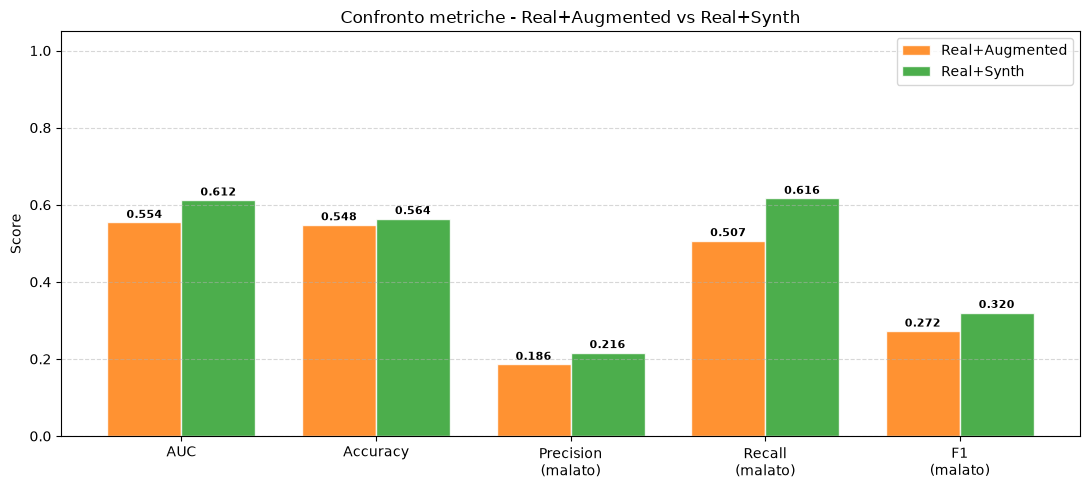

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/metrics_comparison.png
                   AUC Accuracy Precision  Recall      F1 Soglia
Configurazione                                                  
Real+Augmented  0.5541   0.5479    0.1859  0.5068  0.2721  0.428
Real+Synth      0.6122   0.5639    0.2163  0.6164  0.3203  0.285

tabella salvata in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/tables/summary_trad_aug_vs_real_synth.csv


In [13]:
#grafico a barre raggruppate
metric_keys   = ['auc', 'accuracy', 'precision', 'recall', 'f1']
metric_labels = ['AUC', 'Accuracy', 'Precision\n(malato)', 'Recall\n(malato)', 'F1\n(malato)']
x = np.arange(len(metric_keys)); width = 0.38
nomi = list(all_metrics.keys())                                         #iterazione su modelli attivi
fig, ax = plt.subplots(figsize=(11, 5))

#disegna barre ed etichette
for i, nome in enumerate(nomi):
    vals = [all_metrics[nome][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=nome, color=COLORS.get(nome, 'tab:blue'), alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, "%.3f" % v, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width * (len(nomi) - 1) / 2); ax.set_xticklabels(metric_labels)   #centra etichette
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Confronto metriche - Real+Augmented vs Real+Synth')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)             

plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, 'metrics_comparison.png')
fig.savefig(bar_path, dpi=150, bbox_inches='tight')                   
plt.show()
print("salvato in:", bar_path)

#genera e stampa tabella riassuntiva metriche
df_summary = pd.DataFrame([
    {'Configurazione': nome, 'AUC': "%.4f" % m['auc'], 'Accuracy': "%.4f" % m['accuracy'],
     'Precision': "%.4f" % m['precision'], 'Recall': "%.4f" % m['recall'],
     'F1': "%.4f" % m['f1'], 'Soglia': "%.3f" % m['threshold']}
    for nome, m in all_metrics.items()
]).set_index('Configurazione')
print(df_summary.to_string())

#salva tabella in csv
csv_path = os.path.join(TABLES_DIR, 'summary_trad_aug_vs_real_synth.csv')
df_summary.to_csv(csv_path)
print("\ntabella salvata in:", csv_path)

#### Visualizzazione Distribuzione Probabilità Predette
- Le probabilità del test set sono separate per classe reale, la linea tratteggiata è la soglia decisionale.
- Evidenzia la separazione tra sani e malati e dove il modello commette più errori.

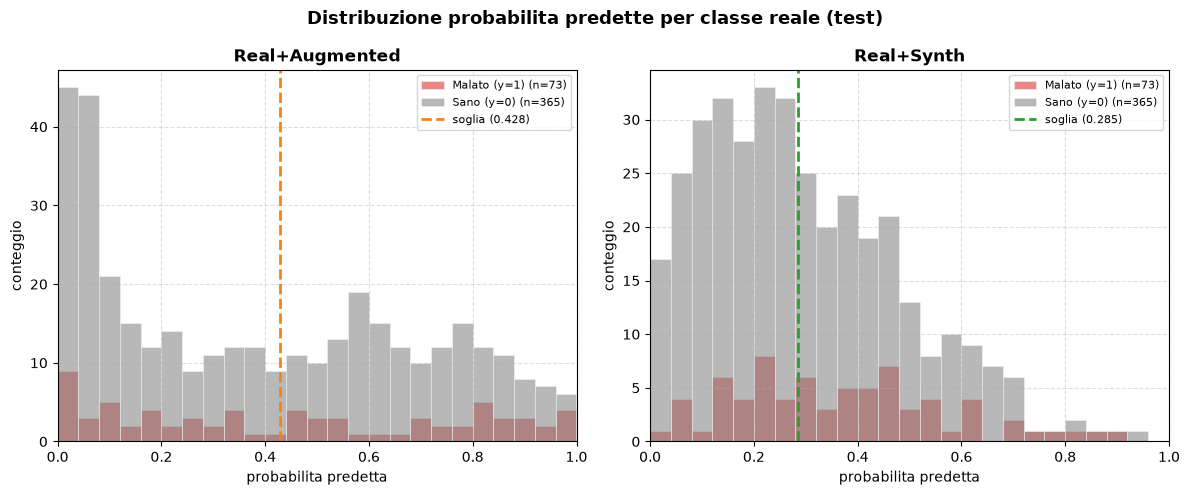

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/prob_dist_trad_aug_vs_real_synth.png


In [14]:
#distribuzione probabilita predette separata per classe reale
COLORI_CLASSE    = {1: 'tab:red', 0: 'tab:gray'}
ETICHETTE_CLASSE = {1: 'Malato (y=1)', 0: 'Sano (y=0)'}

n = len(MODELLI_ATTIVI)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False)           #squeeze=False crea matrice anche con 1 modello
axes = axes[0]

#istogramma probabilita per ogni modello
for ax, nome in zip(axes, MODELLI_ATTIVI):
    probs, soglia = test_probs[nome], soglie[nome]
    for classe in (1, 0):
        maschera = (test_true == classe)
        ax.hist(probs[maschera], bins=25, range=(0, 1), alpha=0.55,
                color=COLORI_CLASSE[classe], edgecolor='white', linewidth=0.5,
                label="%s (n=%d)" % (ETICHETTE_CLASSE[classe], int(maschera.sum())))
    ax.axvline(x=soglia, color=COLORS[nome], linestyle='--', lw=2, label="soglia (%.3f)" % soglia)
    ax.set_xlim(0, 1)
    ax.set_xlabel('probabilita predetta'); ax.set_ylabel('conteggio')
    ax.set_title(nome, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Distribuzione probabilita predette per classe reale (test)', fontsize=13, fontweight='bold')
plt.tight_layout()
dist_path = os.path.join(FIGURES_DIR, 'prob_dist_trad_aug_vs_real_synth.png')
fig.savefig(dist_path, dpi=150, bbox_inches='tight')
plt.show()
print("salvato in:", dist_path)

#### Valutazione con Bootstrap
- Si implementa un bootstrap bilanciato che ad ogni round ricampiona con reinserimento un numero uguale di casi positivi (malati) e negativi (sani), pari al numerodi osservazioni della classe minoritaria.


[Real+Augmented]
  Accuracy   0.5291 +/- 0.0420
  Precision  0.5307 +/- 0.0444
  Recall     0.5049 +/- 0.0602
  F1         0.5165 +/- 0.0486
  ROC_AUC    0.5501 +/- 0.0486

[Real+Synth]
  Accuracy   0.5814 +/- 0.0419
  Precision  0.5774 +/- 0.0402
  Recall     0.6099 +/- 0.0588
  F1         0.5923 +/- 0.0442
  ROC_AUC    0.6068 +/- 0.0484


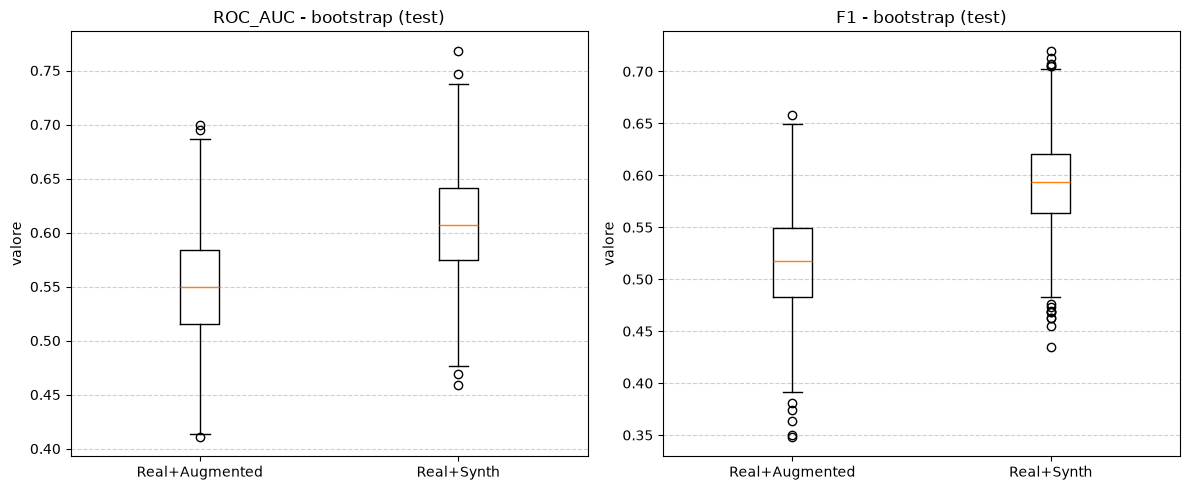

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/bootstrap_comparison.png


In [15]:
#calcola metriche con bootstrap per compensare sbilanciamento classi
def bootstrap_bilanciato(y_true, y_prob, threshold, n_rounds=1000, seed=SEED):
    rng = np.random.default_rng(seed)                                           #generatore casuale
    pos_idx = np.where(y_true == 1)[0]                                          #indici classe positiva
    neg_idx = np.where(y_true == 0)[0]                                          #indici classe negativa
    n = min(len(pos_idx), len(neg_idx))                                         #dimensione pari a classe minoritaria
    out = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'ROC_AUC': []}
    
    for _ in range(n_rounds):
        sel_pos = rng.choice(pos_idx, size=n, replace=True)
        sel_neg = rng.choice(neg_idx, size=n, replace=True)
        idx = np.concatenate([sel_pos, sel_neg])
        yt, yp = y_true[idx], y_prob[idx]
        pred = (yp >= threshold).astype(int)
        
        out['Accuracy'].append(accuracy_score(yt, pred))
        out['Precision'].append(precision_score(yt, pred, pos_label=1, zero_division=0))
        out['Recall'].append(recall_score(yt, pred, pos_label=1, zero_division=0))
        out['F1'].append(f1_score(yt, pred, pos_label=1, zero_division=0))
        out['ROC_AUC'].append(roc_auc_score(yt, yp))
    return out

#esegue bootstrap per modelli e stampa media con deviazione standard
boot = {}
for nome, (probs, thr) in CLASSIFICATORI.items():
    boot[nome] = bootstrap_bilanciato(test_true, probs, thr)
    print("\n[%s]" % nome)
    for k, v in boot[nome].items():
        print("  %-10s %.4f +/- %.4f" % (k, np.mean(v), np.std(v)))

#genera boxplot per confronto AUC e F1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['ROC_AUC', 'F1']):
    ax.boxplot([boot[n][metric] for n in CLASSIFICATORI])
    ax.set_xticklabels(list(CLASSIFICATORI.keys()))
    ax.set_title('%s - bootstrap (test)' % metric)
    ax.set_ylabel('valore'); ax.grid(True, axis='y', linestyle='--', alpha=0.6) 

plt.tight_layout()
boot_path = os.path.join(FIGURES_DIR, 'bootstrap_comparison.png')
fig.savefig(boot_path, dpi=150, bbox_inches='tight')                           
plt.show()
print("salvato in:", boot_path)

#### Visualizzazione Grad-CAM
- Grad-CAM per confrontare le regioni d'interesse dei modelli.
- Vengono selezionati 4 campioni dal test set (2 positivi, 2 negativi).

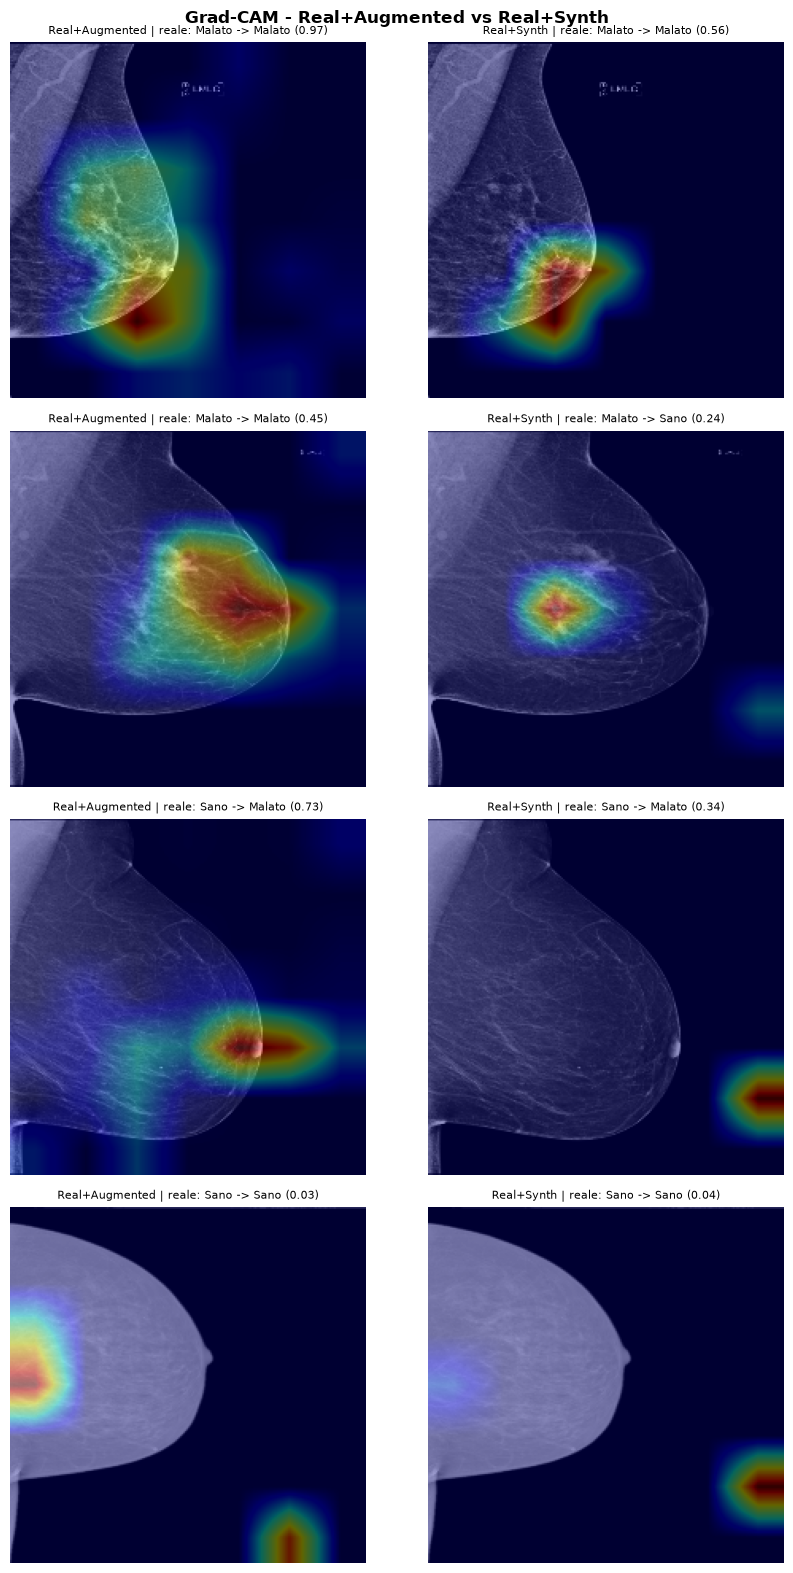

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/gradcam_comparison.png


In [16]:
MEAN_NP = IMAGENET_MEAN.numpy()
STD_NP  = IMAGENET_STD.numpy()

#genera mappa di attivazione rispetto a ultima feature map
def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('resnet50')                                          #layer convoluzionale base
    head_layers = [l for l in model.layers if l.name not in (model.layers[0].name, backbone.name)]  #layer classificazione
    
    #registra operazioni per il calcolo gradienti
    with tf.GradientTape() as tape:                                                 
        backbone_out = backbone(img_array, training=False)
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x
        
    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

#sovrappone heatmap all'immagine denormalizzata
def show_gradcam(img_tensor, heatmap, ax, title=""):
    img_vis = img_tensor.numpy() * STD_NP + MEAN_NP
    img_vis = np.clip(img_vis, 0, 1)[:, :, 0]
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    
    ax.imshow(img_vis, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title, fontsize=8); ax.axis('off')                                 

#seleziona 2 campioni positivi e 2 negativi da test set
sample_pos, sample_neg = [], []
for imgs, etichette in test_ds:
    for i in range(len(imgs)):
        et = int(etichette[i].numpy())
        if et == 1 and len(sample_pos) < 2:
            sample_pos.append((imgs[i], et))
        elif et == 0 and len(sample_neg) < 2:
            sample_neg.append((imgs[i], et))
    if len(sample_pos) >= 2 and len(sample_neg) >= 2:
        break
samples = sample_pos + sample_neg

#griglia subplot per avere matrice 2D anche con singolo modello
classifiers_list = [(nome, modelli[nome], soglie[nome]) for nome in MODELLI_ATTIVI]
fig, axes = plt.subplots(len(samples), len(classifiers_list), figsize=(4.5 * len(classifiers_list), 4 * len(samples)), squeeze=False)

#predizione e disegna grad-cam per ogni campione
for row, (img, et) in enumerate(samples):
    for col, (clf_name, clf_model, clf_thr) in enumerate(classifiers_list):
        img_batch = tf.expand_dims(img, 0)                                          #aggiunge dimensione batch
        prob = float(clf_model.predict(img_batch, verbose=0)[0][0])
        pred = 'Malato' if prob >= clf_thr else 'Sano'
        heatmap = make_gradcam_heatmap(img_batch, clf_model)
        show_gradcam(img, heatmap, axes[row, col], title="%s | reale: %s -> %s (%.2f)" % (clf_name, 'Malato' if et == 1 else 'Sano', pred, prob))

plt.suptitle("Grad-CAM - Real+Augmented vs Real+Synth", fontsize=12, fontweight='bold')
plt.tight_layout()

gradcam_path = os.path.join(FIGURES_DIR, 'gradcam_comparison.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')                             
plt.show()
print("salvato in:", gradcam_path)

#### Trade-off sostenibilita
- Lettura dei log `eco_tracker` di augmentation tradizionale e generazione sintetica.
- Si calcola la % aumento inquinamento (CO2/kWh) vs % aumento prestazioni (AUC).

Riepilogo emissioni
-------------------------------------------------------------------------------------------------------------------
Metodo                   | Fonte   | Energia (kWh) |   CO2 (kg) |  Tempo (s) |   RAM (MB) |    vs Aug (kWh)
-------------------------------------------------------------------------------------------------------------------
Augmentation             | REALE   |      2.23e-05 |   7.38e-06 |         24 |        240 |           1.00x
Diffusore Fine-Tuned     | REALE   |          2.79 |       1.07 |      35588 |       3430 |        125,189x
Diffusore From Scratch   | REALE   |         0.379 |      0.116 |      56935 |       3719 |         16,994x
-------------------------------------------------------------------------------------------------------------------


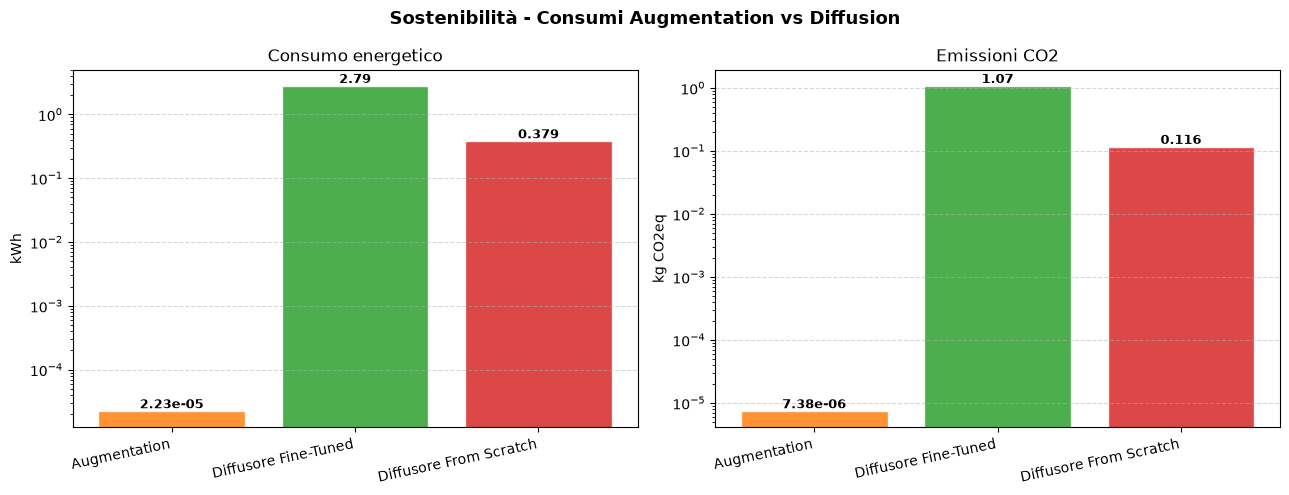

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/eco_consumi_assoluti.png


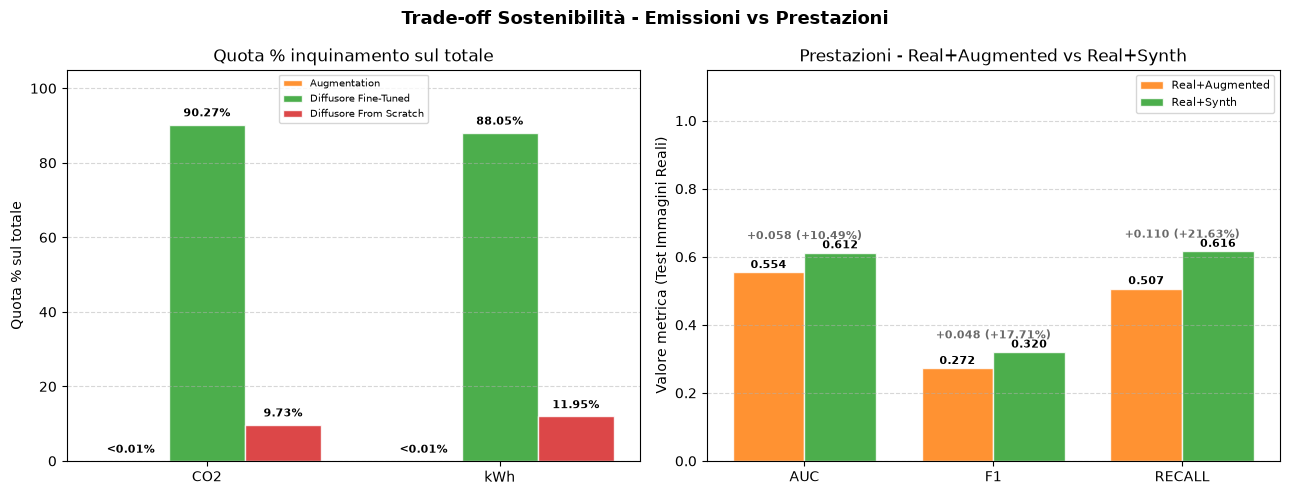

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/eco_tradeoff_inquinamento_vs_prestazioni.png


In [17]:
#root del progetto: tutti i percorsi sono espressi relativi a questa (pathlib)
ROOT = Path(BASE_PATH)
ECO_SOURCES = {
    'Augmentation':           {'path': ROOT / 'results' / '02_data_augmentation' / 'ecotracker' / 'augmentation_ecotracker.json', 'color': 'tab:orange'},
    'Diffusore Fine-Tuned':   {'path': ROOT / 'results' / '03b_finetuning_filtered' / 'ecotracker', 'color': 'tab:green'},
    'Diffusore From Scratch': {'path': ROOT / 'results' / 'TEST-ECOTRACK-FROM-SCRATCH' / 'ecotracker',                              'color': 'tab:red'},
}

#metriche
PERF_METRICS = ['auc', 'f1', 'recall']

#formatta numeri per tabella
def fmt_num(v):
    if not np.isfinite(v): return "n/d"
    a = abs(v)
    if 0 < a < 1e-3: return "%.2e" % v
    if a < 1000:     return "%.2f" % v
    return "{:,.0f}".format(v)

#formatta percentuali
def formatta_perc(v):
    if 0 < v < 0.01: return "<0.01%"
    return "%.2f%%" % v

#chiavi alternative accettate per ciascuna metrica (parsing adattivo)
ECO_KEYS = {
    'energy_kwh':      ['energy_kwh', 'energy', 'kwh', 'energy_consumed_kwh', 'total_energy_kwh', 'energy_consumed'],
    'co2_kg':          ['co2_kg', 'co2', 'co2eq', 'co2_emissions_kg', 'emissions_kg', 'emissions', 'carbon_kg'],
    'elapsed_seconds': ['elapsed_seconds', 'elapsed', 'duration_seconds', 'duration', 'time_seconds', 'runtime_seconds'],
    'peak_ram_mb':     ['peak_ram_mb', 'ram_mb', 'peak_memory_mb', 'peak_ram', 'memory_mb', 'max_ram_mb'],
}

#estrae il primo valore numerico tra le chiavi candidate (robusto a formati diversi)
def _estrai(record, chiavi):
    for k in chiavi:
        if k in record:
            try:
                v = float(record[k])
                if np.isfinite(v):
                    return v
            except (TypeError, ValueError):
                continue
    return None

#legge un file json (dict/lista) o jsonl (un record per riga) -> lista di dict
def _record_da_file(percorso):
    records = []
    try:
        testo = Path(percorso).read_text(encoding='utf-8').strip()
    except OSError:
        return records
    if not testo:
        return records
    try:
        obj = json.loads(testo)
        if isinstance(obj, dict):
            return [obj]
        if isinstance(obj, list):
            return [r for r in obj if isinstance(r, dict)]
    except json.JSONDecodeError:
        pass
    for riga in testo.splitlines():
        riga = riga.strip()
        if not riga:
            continue
        try:
            obj = json.loads(riga)
            if isinstance(obj, dict):
                records.append(obj)
        except json.JSONDecodeError:
            continue
    return records

#aggrega le metriche energetiche da un file singolo o da una cartella di log
def leggi_eco(percorso):
    p = Path(percorso)
    if p.is_dir():
        files = sorted(f for f in p.iterdir() if f.suffix.lower() in ('.json', '.jsonl'))
    elif p.is_file():
        files = [p]
    else:
        return None
    energia = co2 = tempo = ram = 0.0
    trovato = False
    for f in files:
        for rec in _record_da_file(f):
            e = _estrai(rec, ECO_KEYS['energy_kwh'])
            c = _estrai(rec, ECO_KEYS['co2_kg'])
            t = _estrai(rec, ECO_KEYS['elapsed_seconds'])
            r = _estrai(rec, ECO_KEYS['peak_ram_mb'])
            if e is not None: energia += e; trovato = True
            if c is not None: co2 += c; trovato = True
            if t is not None: tempo += t
            if r is not None: ram = max(ram, r)
    if not trovato:
        return None
    return {'energy_kwh': energia, 'co2_kg': co2, 'elapsed_seconds': tempo, 'peak_ram_mb': ram}

#carica solo dati REALI: le sorgenti senza log vengono saltate con un avviso (niente valori finti)
eco, fonte = {}, {}
for nome, cfg in ECO_SOURCES.items():
    dati = leggi_eco(cfg['path'])
    if dati is not None:
        eco[nome], fonte[nome] = dati, 'REALE'
    else:
        print("log eco mancanti per '%s' -> sorgente saltata (%s)" % (nome, cfg['path']))

#metodi effettivamente disponibili (solo quelli con log reali)
metodi = [n for n in ECO_SOURCES if n in eco]
if not metodi:
    print("nessun log di sostenibilita trovato: grafici consumi non disponibili")

base_kwh = eco['Augmentation']['energy_kwh'] if 'Augmentation' in eco else float('nan')
base_co2 = eco['Augmentation']['co2_kg'] if 'Augmentation' in eco else float('nan')

#stampa tabella console
print("Riepilogo emissioni")
print("-" * 115)
print("%-24s | %-7s | %13s | %10s | %10s | %10s | %15s" % ("Metodo", "Fonte", "Energia (kWh)", "CO2 (kg)", "Tempo (s)", "RAM (MB)", "vs Aug (kWh)"))
print("-" * 115)

for nome in metodi:
    e = eco[nome]
    mult_kwh = e['energy_kwh'] / base_kwh if base_kwh else float('nan')
    print("%-24s | %-7s | %13.3g | %10.3g | %10.0f | %10.0f | %14sx" % (nome, fonte[nome], e['energy_kwh'], e['co2_kg'], e['elapsed_seconds'], e['peak_ram_mb'], fmt_num(mult_kwh)))
print("-" * 115)

#genera grafici assoluti (solo metodi con log reali)
colori  = [ECO_SOURCES[n]['color'] for n in metodi]
xlabels = [n + (' *' if fonte[n] == 'MOCK' else '') for n in metodi]
x = np.arange(len(metodi))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
configs = zip(axes, ['energy_kwh', 'co2_kg'], ['Consumo energetico', 'Emissioni CO2'], ['kWh', 'kg CO2eq'])

for ax, key, titolo, unita in configs:
    vals = [eco[n][key] for n in metodi]
    bars = ax.bar(x, vals, color=colori, alpha=0.85, edgecolor='white')
    ax.set_yscale('log'); ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=12, ha='right')
    ax.set_ylabel(unita); ax.set_title(titolo); ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v, "%.3g" % v, ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Sostenibilità - Consumi Augmentation vs Diffusion', fontsize=13, fontweight='bold')
plt.tight_layout()

eco_path = os.path.join(FIGURES_DIR, 'eco_consumi_assoluti.png')
fig.savefig(eco_path, dpi=150, bbox_inches='tight')                                 #salva grafico
plt.show(); print("salvato in:", eco_path)

#calcola trade-off
tot_co2 = sum(eco[n]['co2_kg'] for n in metodi)
tot_kwh = sum(eco[n]['energy_kwh'] for n in metodi)
quota = {n: {'co2': (eco[n]['co2_kg'] / tot_co2 * 100) if tot_co2 else float('nan'), 'kwh': (eco[n]['energy_kwh'] / tot_kwh * 100) if tot_kwh else float('nan')} for n in metodi}

#salta plot trade-off se manca uno dei due modelli
if 'Real+Augmented' in all_metrics and 'Real+Synth' in all_metrics:
    pct_perf = {m: (all_metrics['Real+Synth'][m] - all_metrics['Real+Augmented'][m]) / all_metrics['Real+Augmented'][m] * 100 if all_metrics['Real+Augmented'][m] else float('nan') for m in PERF_METRICS}

    fig, (axc, axp) = plt.subplots(1, 2, figsize=(13, 5))
    inq_keys, inq_lab = ['co2', 'kwh'], ['CO2', 'kWh']
    xi = np.arange(len(inq_keys)); w = 0.26
    
    #plot costi
    for i, nome in enumerate(metodi):
        vals = [quota[nome][k] for k in inq_keys]
        label = nome + (' *' if fonte[nome] == 'MOCK' else '')
        b = axc.bar(xi + i * w, vals, w, color=ECO_SOURCES[nome]['color'], alpha=0.85, edgecolor='white', label=label)
        for bar, v in zip(b, vals):
            axc.text(bar.get_x() + bar.get_width() / 2, v + 1.5, formatta_perc(v), ha='center', va='bottom', fontsize=8, fontweight='bold')
            
    axc.set_xticks(xi + w); axc.set_xticklabels(inq_lab); axc.set_ylim(0, 105)
    axc.set_ylabel('Quota % sul totale'); axc.set_title('Quota % inquinamento sul totale')
    axc.legend(fontsize=7); axc.grid(True, axis='y', linestyle='--', alpha=0.5)

    #plot benefici
    modelli_perf = [m for m in ('Real+Augmented', 'Real+Synth') if m in all_metrics]
    xp = np.arange(len(PERF_METRICS)); wp = 0.38
    
    for i, nome in enumerate(modelli_perf):
        vals = [all_metrics[nome][m] for m in PERF_METRICS]
        b = axp.bar(xp + i * wp, vals, wp, color=COLORS.get(nome, 'tab:blue'), alpha=0.85, edgecolor='white', label=nome)
        for bar, v in zip(b, vals):
            axp.text(bar.get_x() + bar.get_width() / 2, v + 0.005, "%.3f" % v, ha='center', va='bottom', fontsize=8, fontweight='bold')
            
    #aggiunge annotazioni delta su barre plot benefici
    for j, m in enumerate(PERF_METRICS):
        d = all_metrics['Real+Synth'][m] - all_metrics['Real+Augmented'][m]
        ymax = max(all_metrics['Real+Augmented'][m], all_metrics['Real+Synth'][m])
        axp.annotate("%+.3f (%+.2f%%)" % (d, pct_perf[m]), xy=(xp[j] + wp / 2, ymax + 0.04), ha='center', fontsize=8, color='dimgray', fontweight='bold')
                     
    axp.set_xticks(xp + wp / 2); axp.set_xticklabels([m.upper() for m in PERF_METRICS])
    axp.set_ylim(0, 1.15); axp.set_ylabel('Valore metrica (Test Immagini Reali)')
    axp.set_title('Prestazioni - Real+Augmented vs Real+Synth'); axp.legend(fontsize=8); axp.grid(axis='y', linestyle='--', alpha=0.5)

    fig.suptitle('Trade-off Sostenibilità - Emissioni vs Prestazioni', fontsize=13, fontweight='bold')
    plt.tight_layout()
    
    tradeoff_path = os.path.join(FIGURES_DIR, 'eco_tradeoff_inquinamento_vs_prestazioni.png')
    fig.savefig(tradeoff_path, dpi=150, bbox_inches='tight')                       
    plt.show(); print("salvato in:", tradeoff_path)
    
else:
    print("\nservono entrambi i modelli attivi - calcolo trade-off ignorato")

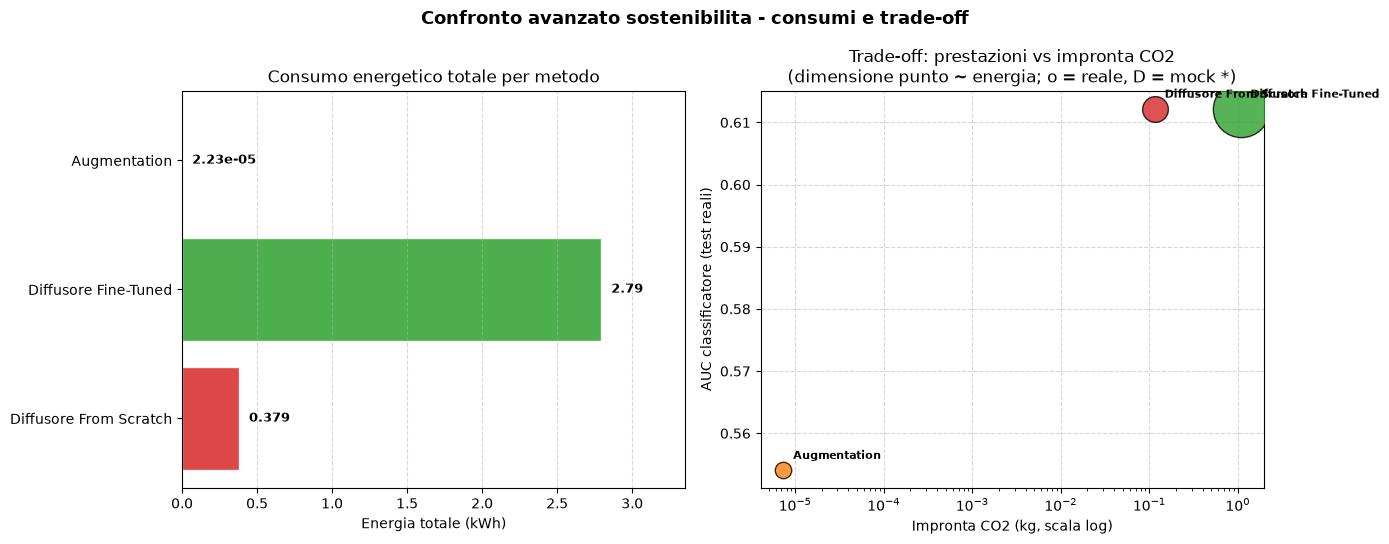

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/eco_confronto_avanzato.png


In [18]:
#### grafici comparativi avanzati sostenibilita (consumi totali + trade-off prestazioni/impronta)
#riusa eco, fonte, ECO_SOURCES, all_metrics calcolati nella cella precedente

#auc per metodo: augmentation -> classificatore Real+Augmented, diffusori -> Real+Synth
auc_aug   = all_metrics.get('Real+Augmented', {}).get('auc', float('nan'))
auc_synth = all_metrics.get('Real+Synth', {}).get('auc', float('nan'))
PERF_PER_METODO = {
    'Augmentation':           auc_aug,
    'Diffusore Fine-Tuned':   auc_synth,
    'Diffusore From Scratch': auc_synth,
}

metodi_cmp = [n for n in ECO_SOURCES if n in eco]
energie    = [eco[n]['energy_kwh'] for n in metodi_cmp]
emax       = max(energie) if energie and max(energie) > 0 else 1.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

#--- grafico 1: bar chart consumi energetici totali per metodo ---
lab = [n + (' *' if fonte[n] == 'MOCK' else '') for n in metodi_cmp]
col = [ECO_SOURCES[n]['color'] for n in metodi_cmp]
yp  = np.arange(len(metodi_cmp))
barre = ax1.barh(yp, energie, color=col, alpha=0.85, edgecolor='white')
ax1.set_yticks(yp); ax1.set_yticklabels(lab); ax1.invert_yaxis()
ax1.set_xlabel('Energia totale (kWh)')
ax1.set_title('Consumo energetico totale per metodo')
ax1.grid(True, axis='x', linestyle='--', alpha=0.5)
ax1.margins(x=0.20)
for bar, v in zip(barre, energie):
    ax1.text(v, bar.get_y() + bar.get_height() / 2, '  %.3g' % v, va='center', ha='left', fontsize=9, fontweight='bold')

#--- grafico 2: scatter trade-off prestazioni (AUC) vs impronta CO2 ---
for n in metodi_cmp:
    x, y = eco[n]['co2_kg'], PERF_PER_METODO[n]
    if not (np.isfinite(x) and np.isfinite(y) and x > 0):
        continue
    dim = 140 + 1500 * (eco[n]['energy_kwh'] / emax)
    mk  = 'o' if fonte[n] == 'REALE' else 'D'
    ax2.scatter(x, y, s=dim, color=ECO_SOURCES[n]['color'], alpha=0.8, edgecolor='black', marker=mk, zorder=3)
    ax2.annotate(n + (' *' if fonte[n] == 'MOCK' else ''), xy=(x, y), xytext=(7, 8), textcoords='offset points', fontsize=8, fontweight='bold')
ax2.set_xscale('log')
ax2.set_xlabel('Impronta CO2 (kg, scala log)')
ax2.set_ylabel('AUC classificatore (test reali)')
ax2.set_title('Trade-off: prestazioni vs impronta CO2\n(dimensione punto ~ energia; o = reale, D = mock *)')
ax2.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Confronto avanzato sostenibilita - consumi e trade-off', fontsize=13, fontweight='bold')
plt.tight_layout()

cmp_path = os.path.join(FIGURES_DIR, 'eco_confronto_avanzato.png')
fig.savefig(cmp_path, dpi=150, bbox_inches='tight')
plt.show(); print('salvato in:', cmp_path)

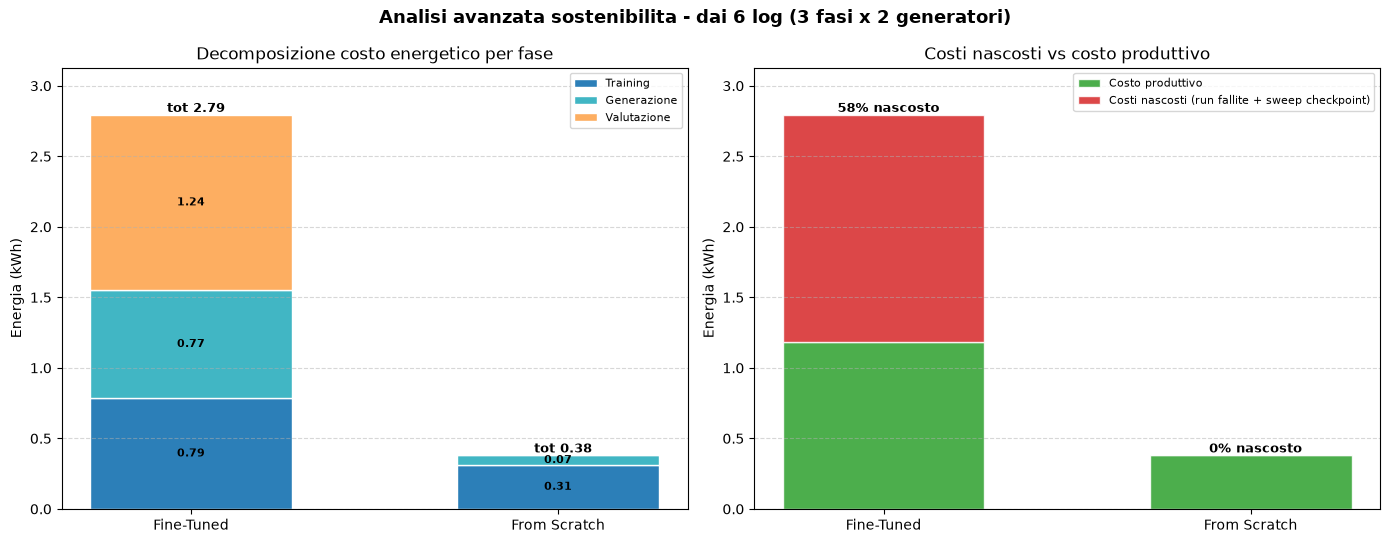

salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/figures/eco_analisi_avanzata_fasi.png

INSIGHT SOSTENIBILITA (spunti per la relazione)

Diffusore Fine-Tuned -> 2.793 kWh | 1.074 kg CO2
   Training     0.785 kWh (28.1%)
   Generazione  0.767 kWh (27.5%)
   Valutazione  1.241 kWh (44.4%)
   equivale a ~9.0 km in auto o ~233 ricariche di smartphone
   costi nascosti: 1.610 kWh (58%) tra run fallite e selezione checkpoint
   5444 immagini generate -> 0.1408 kWh per 1000 img (costo marginale di generazione)
   qualita generatore: FID 129.3

Diffusore From Scratch -> 0.379 kWh | 0.116 kg CO2
   Training     0.313 kWh (82.4%)
   Generazione  0.066 kWh (17.5%)
   Valutazione  0.000 kWh ( 0.1%)
   equivale a ~1.0 km in auto o ~32 ricariche di smartphone

costo ambientale del guadagno prestazionale (+0.0581 AUC):
   Diffusore Fine-Tuned: 0.185 kg CO2 per +0.01 AUC
   Diffusore From Scratch: 0.020 kg CO2 per +0.01 AUC


In [19]:
#### analisi avanzata sostenibilita generatori (sfrutta i 6 log: 3 fasi x 2 config)
#riusa ECO_SOURCES, _record_da_file, _estrai, ECO_KEYS, all_metrics, FIGURES_DIR dalle celle precedenti

#equivalenze concrete per dare un senso ai numeri (medie indicative)
KM_AUTO_PER_KG     = 1000.0 / 120.0   #~120 g CO2 per km in auto
SMARTPHONE_PER_KWH = 1000.0 / 12.0    #~12 Wh per ricarica completa smartphone

#classifica un file di log in una fase del ciclo di vita del generatore
def classifica_fase(fname, labels):
    txt = (fname + ' ' + ' '.join(str(l) for l in labels)).lower()
    if any(k in txt for k in ('finetun', 'vae_training', 'ldm_training', 'training', '_train')):
        return 'Training'
    if 'pipeline' in fname.lower() or any(k in txt for k in ('generation', 'generate_raw', 'final_gen', 'gen_')):
        return 'Generazione'
    if any(k in txt for k in ('valid', 'eval', 'checkpoint')):
        return 'Valutazione'
    return 'Generazione'

FASI      = ['Training', 'Generazione', 'Valutazione']
DIFFUSORI = [n for n in ('Diffusore Fine-Tuned', 'Diffusore From Scratch') if n in ECO_SOURCES]

#per ogni generatore: costo per fase, costi nascosti, immagini generate, qualita (FID)
breakdown = {n: {f: {'energy_kwh': 0.0, 'co2_kg': 0.0} for f in FASI} for n in DIFFUSORI}
extra     = {n: {'tot_kwh': 0.0, 'fallite_kwh': 0.0, 'sweep_kwh': 0.0, 'nascosto_kwh': 0.0, 'immagini': 0, 'fid': None} for n in DIFFUSORI}

for nome in DIFFUSORI:
    p = Path(ECO_SOURCES[nome]['path'])
    if not p.is_dir():
        continue
    for f in sorted(x for x in p.iterdir() if x.suffix.lower() in ('.json', '.jsonl')):
        recs   = _record_da_file(f)
        labels = [r.get('label', r.get('phase', '')) for r in recs]
        fase   = classifica_fase(f.name, labels)
        for r in recs:
            e = _estrai(r, ECO_KEYS['energy_kwh']) or 0.0
            c = _estrai(r, ECO_KEYS['co2_kg']) or 0.0
            breakdown[nome][fase]['energy_kwh'] += e
            breakdown[nome][fase]['co2_kg']     += c
            extra[nome]['tot_kwh'] += e
            failed = str(r.get('status', '')).lower() in ('failed', 'error') or (r.get('returncode', 0) not in (0, None))
            sweep  = float(r.get('n_checkpoints', 0) or 0) > 1
            if failed: extra[nome]['fallite_kwh'] += e
            if sweep:  extra[nome]['sweep_kwh']   += e
            if failed or sweep: extra[nome]['nascosto_kwh'] += e
            nfin = (r.get('n_positive_final') or 0) + (r.get('n_negative_final') or 0)
            extra[nome]['immagini'] = max(extra[nome]['immagini'], int(nfin))
            if r.get('avg_FID') is not None: extra[nome]['fid'] = float(r['avg_FID'])

#=== grafici ===
col_fase = {'Training': '#2c7fb8', 'Generazione': '#41b6c4', 'Valutazione': '#fdae61'}
x = np.arange(len(DIFFUSORI))
etich = [n.replace('Diffusore ', '') for n in DIFFUSORI]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5.5))

#A: decomposizione energia per fase (stacked) -> mostra DOVE si spende
bottom = np.zeros(len(DIFFUSORI))
for fase in FASI:
    vals = np.array([breakdown[n][fase]['energy_kwh'] for n in DIFFUSORI])
    axA.bar(x, vals, 0.55, bottom=bottom, label=fase, color=col_fase[fase], edgecolor='white')
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.01:
            axA.text(xi, b + v / 2, '%.2f' % v, ha='center', va='center', fontsize=8, fontweight='bold')
    bottom += vals
for xi in range(len(DIFFUSORI)):
    axA.text(xi, bottom[xi], '  tot %.2f' % bottom[xi], ha='center', va='bottom', fontsize=9, fontweight='bold')
axA.set_xticks(x); axA.set_xticklabels(etich)
axA.set_ylabel('Energia (kWh)'); axA.set_title('Decomposizione costo energetico per fase')
axA.legend(fontsize=8); axA.grid(True, axis='y', linestyle='--', alpha=0.5); axA.margins(y=0.12)

#B: costi nascosti (run fallite + sweep selezione checkpoint) vs costo produttivo
nasc = np.array([extra[n]['nascosto_kwh'] for n in DIFFUSORI])
util = np.array([max(extra[n]['tot_kwh'] - extra[n]['nascosto_kwh'], 0.0) for n in DIFFUSORI])
axB.bar(x, util, 0.55, label='Costo produttivo', color='tab:green', alpha=0.85, edgecolor='white')
axB.bar(x, nasc, 0.55, bottom=util, label='Costi nascosti (run fallite + sweep checkpoint)', color='tab:red', alpha=0.85, edgecolor='white')
for xi, n in enumerate(DIFFUSORI):
    tot = extra[n]['tot_kwh']; perc = (nasc[xi] / tot * 100) if tot else 0.0
    axB.text(xi, tot, '  %.0f%% nascosto' % perc, ha='center', va='bottom', fontsize=9, fontweight='bold')
axB.set_xticks(x); axB.set_xticklabels(etich)
axB.set_ylabel('Energia (kWh)'); axB.set_title('Costi nascosti vs costo produttivo')
axB.legend(fontsize=8); axB.grid(True, axis='y', linestyle='--', alpha=0.5); axB.margins(y=0.12)

fig.suptitle('Analisi avanzata sostenibilita - dai 6 log (3 fasi x 2 generatori)', fontsize=13, fontweight='bold')
plt.tight_layout()
adv_path = os.path.join(FIGURES_DIR, 'eco_analisi_avanzata_fasi.png')
fig.savefig(adv_path, dpi=150, bbox_inches='tight'); plt.show(); print('salvato in:', adv_path)

#=== insight testuali (spunti per la relazione / prof) ===
print(''); print('=' * 70); print('INSIGHT SOSTENIBILITA (spunti per la relazione)'); print('=' * 70)
for n in DIFFUSORI:
    tk = sum(breakdown[n][f]['energy_kwh'] for f in FASI)
    tc = sum(breakdown[n][f]['co2_kg'] for f in FASI)
    if tk == 0: continue
    print(''); print('%s -> %.3f kWh | %.3f kg CO2' % (n, tk, tc))
    for f in FASI:
        e = breakdown[n][f]['energy_kwh']
        if e > 0: print('   %-12s %.3f kWh (%4.1f%%)' % (f, e, e / tk * 100))
    print('   equivale a ~%.1f km in auto o ~%.0f ricariche di smartphone' % (tc * KM_AUTO_PER_KG, tk * SMARTPHONE_PER_KWH))
    if extra[n]['nascosto_kwh'] > 0:
        print('   costi nascosti: %.3f kWh (%.0f%%) tra run fallite e selezione checkpoint' % (extra[n]['nascosto_kwh'], extra[n]['nascosto_kwh'] / tk * 100))
    if extra[n]['immagini'] > 0:
        print('   %d immagini generate -> %.4f kWh per 1000 img (costo marginale di generazione)' % (extra[n]['immagini'], breakdown[n]['Generazione']['energy_kwh'] / extra[n]['immagini'] * 1000))
    if extra[n]['fid'] is not None:
        print('   qualita generatore: FID %.1f' % extra[n]['fid'])

#costo ambientale per punto di AUC guadagnato (Real+Synth vs Real+Augmented)
if 'Real+Augmented' in all_metrics and 'Real+Synth' in all_metrics:
    d_auc = all_metrics['Real+Synth']['auc'] - all_metrics['Real+Augmented']['auc']
    print(''); print('costo ambientale del guadagno prestazionale (%+.4f AUC):' % d_auc)
    for n in DIFFUSORI:
        tc = sum(breakdown[n][f]['co2_kg'] for f in FASI)
        if d_auc > 0 and tc > 0:
            print('   %s: %.3f kg CO2 per +0.01 AUC' % (n, tc / (d_auc * 100)))

#### Considerazioni finali (esempio)
- **AUC metrica primaria:** soglie di Youden basse e instabili (Real+Augmented ~0.12); metriche threshold-dependent (F1, Recall) risultano fragili.
- **Confronto Real+Augmented vs Real+Synth:** margine Real+Synth (+0.027 AUC) rientra in deviazione standard bootstrap (~+/-0.046). Vantaggio della generazione presente ma non statisticamente robusto a causa di limitata numerosità (73 positivi in test).
- **Bootstrap:** sovrapposizione intervalli di confidenza conferma mancanza di robustezza del lift prestazionale.
- **Emissioni (D3):** consumi e CO2 di generazione e augmentation misurati a monte da `eco_tracker`; se i log sono presenti l'ultima cella riporta il trade-off % inquinamento vs % prestazioni, altrimenti il bilancio resta demandato alla generazione.